# HOMEWORK 4

Done by: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/ComputerVision-PBY_HW4

In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "numpy",
#     "matplotlib",
#     "opencv-python",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input images
# hm_version = 4
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/ComputerVision-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_CV_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone images
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

For this homework you are going to implement a lane line detector. Lane line detection is crucial for ADAS (Advanced Driver Assistance Systems) systems and, in particular, for LKA (Lane Keep Assist). You will use a [picture](https://en.wikipedia.org/wiki/Lane_departure_warning_system) from a front facing camera (mounted on the car) and will implement the following steps:
* Convert image to gray scale
* Compute edge map
* Apply Hough transform to obtain line parametrizations

In [3]:
# Load data

from pathlib import Path

import cv2

import apps.reporter as rpt

# Input data
file_name = "resources/images/dashcam.jpg"

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

# Convert it to RGB
if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb = cv2.resize(img_rgb, None, fx=0.5, fy=0.5)

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")


Attribute,Result
"(rows, cols, channels)","(600, 800, 3)"


Let's load and show the camera frame.

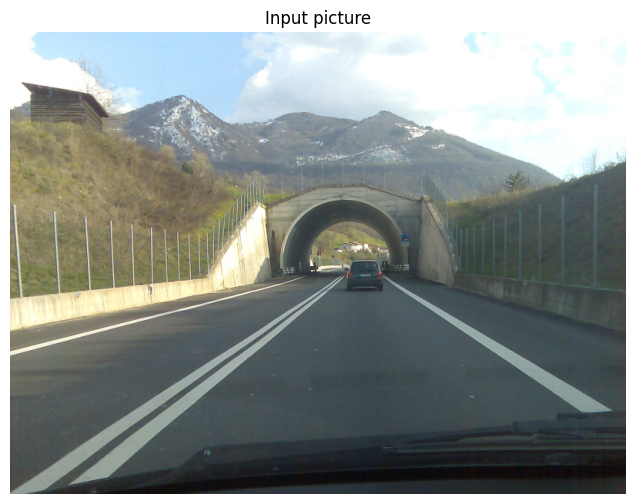

In [4]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = img_rgb

# Solution
_, ax = plt.subplots(figsize=(9, 6))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Input picture")
plt.show()


In [5]:
# Lane line detection - Required version

import cv2
import math
import numpy as np
from sklearn.cluster import KMeans

# Input data
rng_seed = 42
# (0, 0) auto-adaptation of the kernel
blur_ksize = (3, 3)
# 0 auto-adaptation of the sigma
blur_sigmaX = 0
canny_th_low = 100
canny_th_high = 150
# recommended
hough_rho = 2
hough_theta_deg = 2
hough_th = 190
# # for testing
# hough_rho = 1
# hough_theta_deg = 0.5
# hough_th = 50
# angle threshold
hough_theta_th_deg = 20
kmean_n_clusters = 6

# Solution

# Convert image to gray scale
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Apply Gaussian blur to reduce noise
blur = cv2.GaussianBlur(gray, ksize=blur_ksize, sigmaX=blur_sigmaX)

# Obtain edge map
# Hint: you can use Canny edge detector with th_low = 100, th_high = 150
edges = cv2.Canny(gray, threshold1=canny_th_low, threshold2=canny_th_high)

# Pruning
cropped = edges.copy()
cropped[0:350, :] = 0

# Apply Hough transform to parametrize the lines
# Hint 1: Offset resolution of 2 pixels and slope resolution of 2 degrees work well in this case
# Hint 2: A suitable value for the accumulator threshold is 190
lines = cv2.HoughLines(cropped, rho=hough_rho, theta=np.radians(hough_theta_deg), threshold=hough_th)
# Let's get rid of the unnecessary dimension
# lines = lines[:, 0, :] -> alternative
# remove all dimensions of size 1
lines = np.squeeze(lines)

# hough = cropped.copy() -> alternative
hough_lines_1 = np.copy(cropped)
hough_lines_2 = np.copy(img_rgb)
hough_lines_1f = np.copy(cropped)
hough_lines_2f = np.copy(img_rgb)
hough_lines_1c = np.copy(cropped)
hough_lines_2c = np.copy(img_rgb)

# Plot the resulting Hough lines
for line in lines:
    rho, theta = line

    a = math.cos(theta)
    b = math.sin(theta)

    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))
    pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))

    cv2.line(hough_lines_1, pt1, pt2, 255, 1, cv2.LINE_AA)
    cv2.line(hough_lines_2, pt1, pt2, (255, 0, 0), 2, cv2.LINE_AA)

# The edge map looks good but the Hough lines are too noisy. Let's clean the Hough lines first by removing all lines that we know cannot represent a lane line. In other words, all lines that are approximately horizontal shall be removed. Remember that horizontal lines correspond to theta = 90 degrees.

# Filter out all lines that are approximately horizontal (+/- 20 degrees).
filtered_lines = []
for line in lines:
    # Extract theta for current line (remember Hough works with radians)
    theta_deg = np.degrees(line[1])

    # Keep line if theta is not horizontal
    if (theta_deg < 90 - hough_theta_th_deg) or (90 + hough_theta_th_deg < theta_deg):
        filtered_lines.append(line)

# Plot the resulting Hough lines
for line in filtered_lines:
    rho, theta = line

    a = math.cos(theta)
    b = math.sin(theta)

    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))
    pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))

    cv2.line(hough_lines_1f, pt1, pt2, 255, 1, cv2.LINE_AA)
    cv2.line(hough_lines_2f, pt1, pt2, (255, 0, 0), 2, cv2.LINE_AA)

# The result is now much better, but still we see some very similar lines. How can we get rid of them?
# Let's apply k-means clustering. It will find the clusters of the 6 we see in the picture lines and use the averages.

# We will apply k-means clustering to refine the detected lines.
# Don't worry, we will learn about the clustering later in the course :-)
kmeans = KMeans(
    n_clusters=kmean_n_clusters,  # number of necessary clasters
    init="k-means++",  # smart start choosing of the cluster center
    random_state=rng_seed,  # install the seed to get the same results each time
    n_init=10,  # repeat 10 times and take the best result
)
# Note. I used it from a Data Science course

kmeans.fit(filtered_lines)
clustered_lines = kmeans.cluster_centers_

# Plot the resulting Hough lines
for line in clustered_lines:
    rho, theta = line

    a = math.cos(theta)
    b = math.sin(theta)

    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))
    pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))

    cv2.line(hough_lines_1c, pt1, pt2, 255, 1, cv2.LINE_AA)
    cv2.line(hough_lines_2c, pt1, pt2, (255, 0, 0), 2, cv2.LINE_AA)

# Print results
images_dict = {
    "Original image": img_rgb,
    "Grayscale image": gray,
    "Blurred image": blur,
    "Canny-edge map": edges,
    "Cropped map": cropped,
    "Hough lines Black-White": hough_lines_1,
    "Hough lines Colored": hough_lines_2,
    "Hough filtered lines Black-White": hough_lines_1f,
    "Hough filtered lines Colored": hough_lines_2f,
    "Hough clustered lines Black-White": hough_lines_1c,
    "Hough clustered lines Colored": hough_lines_2c,
}


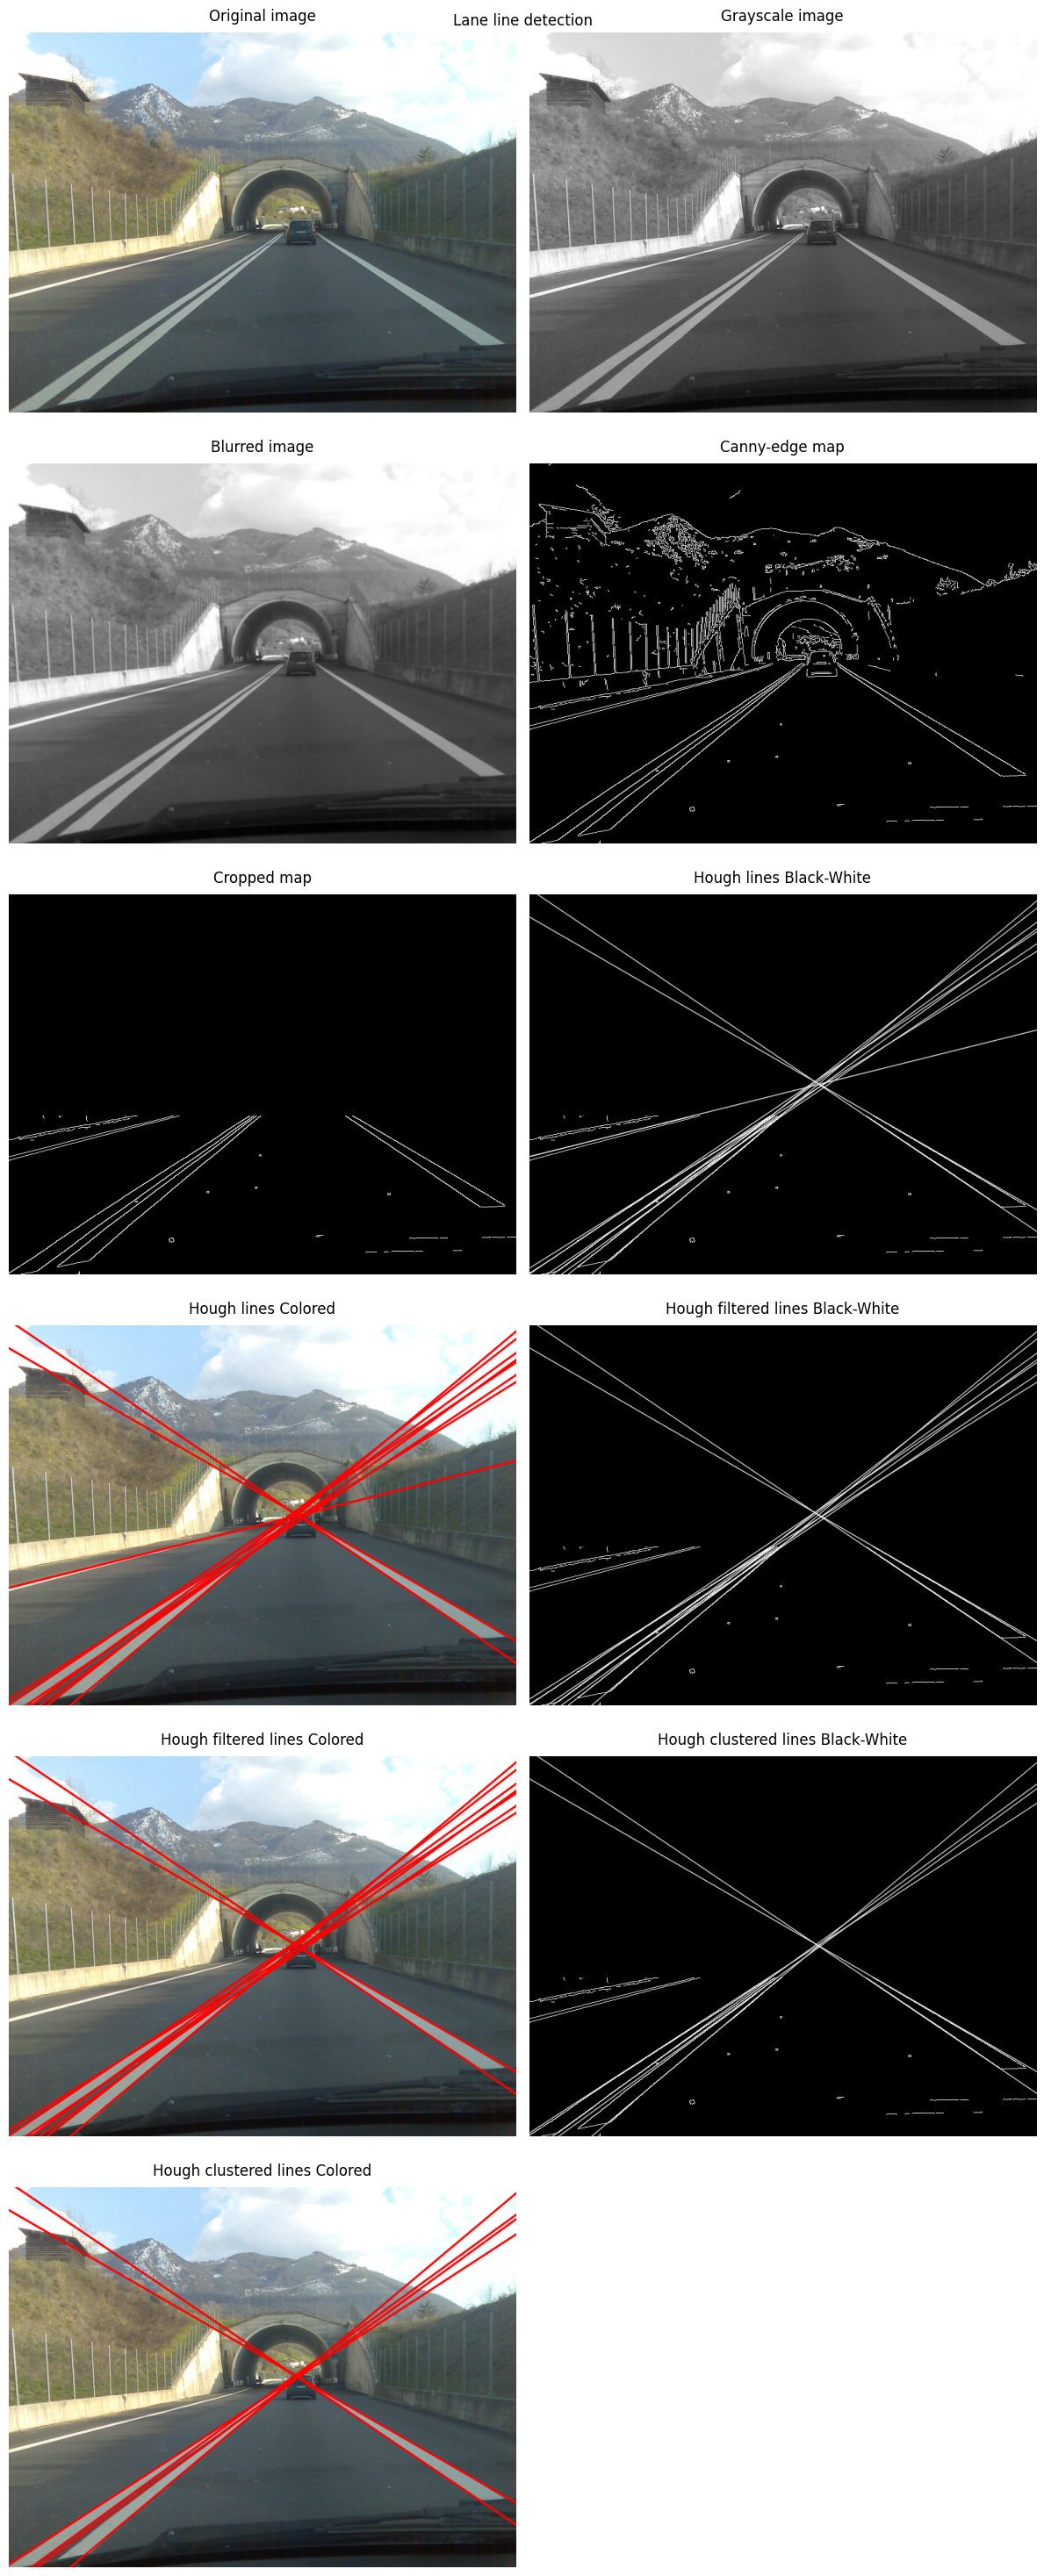

In [6]:
# Graphic results

import math
import numpy as np
import matplotlib.pyplot as plt

# Input data
n_img_cols = 2
n_img_rows = math.ceil(len(images_dict) / n_img_cols)

# Solution
_, axes = plt.subplots(n_img_rows, n_img_cols, figsize=(12, 5 * n_img_rows))
axes_list = np.array(axes).flatten()

for idx, (img_name, img_data) in enumerate(images_dict.items()):
    ax = axes_list[idx]
    ax.set_title(img_name, pad=10, loc='center', color='black')
    if len(img_data.shape) == 3:
        ax.imshow(img_data)
    else:
        ax.imshow(img_data, cmap='gray')
    ax.axis(False)

# remove empty charts
for idx in range(len(images_dict), len(axes_list)):
    axes_list[idx].remove()

# Plot
plt.suptitle("Lane line detection")
plt.tight_layout()
plt.show()


### Questions
* Do you see anything strange in the final result?
* Do you think the Hough transform resolution is important for obtaining a good result? Why?
* Do you think the Hough transform accumulator threshold is important for obtaining a good result? Why?

### Answers
1. Yes, it is noticeable in the final result that the clustering stage caused the resulting lines to be averaged out. As a result, they lost precision and do not perfectly align with or highlight the required fragments.
2. Yes, the Hough transform resolution (both distance and angular step) is critical and must be carefully optimized. If the step size is too large, the algorithm is highly likely to miss important geometric details. Conversely, choosing too small of a step size introduces excessive noise and redundant lines. This noise degrades the performance of the subsequent clustering step, making it difficult to isolate the target region accurately.
3. Yes, the accumulator threshold is crucial for achieving a good result. It determines the minimum number of points (votes) required to detect a line. A threshold that is too low generates a large amount of noisy, false-positive lines. On the other hand, setting the threshold too high increases the likelihood of missing critical lines that fail to accumulate enough votes.

In [39]:
# Lane line detection - Experiment version with my idea

import cv2
import numpy as np
from collections import Counter
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# Input data
# (0, 0) auto-adaptation of the kernel
blur_ksize = (3, 3)
# 0 auto-adaptation of the sigma
blur_sigmaX = 0
canny_th_low = 100
canny_th_high = 150
# radius in pixels
search_radius = 1
# number pixel inside circle
pixels_th = 3
# number pixel for line
pixels_line_th = 190
dispersion_th = 0.99
angle_th_deg = 20

# Solution
eps_radius = np.sqrt(2 * search_radius ** 2)
eps_radius = np.ceil(100 * eps_radius) / 100

# Convert image to gray scale
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Apply Gaussian blur to reduce noise
blur = cv2.GaussianBlur(gray, ksize=blur_ksize, sigmaX=blur_sigmaX)

# Obtain edge map
# Hint: you can use Canny edge detector with th_low = 100, th_high = 150
edges = cv2.Canny(gray, threshold1=canny_th_low, threshold2=canny_th_high)

# Pruning
cropped = edges.copy()
cropped[0:350, :] = 0

#### Using DBSCAN, find clusters that have the necessary number of points for a line ####

# filtering pixels and convert in list of couples
filtered_pixels = np.argwhere(cropped > 0)

# clustering data
dbscan = DBSCAN(
    eps=eps_radius,
    min_samples=pixels_th,
    algorithm="ball_tree"
)
# Note. I used it from a Data Science course

dbscan.fit(filtered_pixels)
labels = dbscan.labels_

# dictionary {cluster id, count of points}
clusters = Counter(labels)
# remove noise
if -1 in clusters:
    del clusters[-1]
# filtration
filtered_clusters_ids = [int(cluster_id) for cluster_id, count in clusters.items() if count >= pixels_line_th]
# create a mask
mask_filtered_pixels = np.isin(labels, filtered_clusters_ids)
# clean pixels by mask
cleaned_pixels = filtered_pixels[mask_filtered_pixels]

# create filtered image
dbscan_clusters = np.zeros_like(cropped)
dbscan_clusters[cleaned_pixels[:, 0], cleaned_pixels[:, 1]] = 255

#### Final filtering clusters by angle ####

pca = PCA(n_components=1)
# Note. I used it from a Data Science course

# dictionary {cluster_id, eigendata} => {cluster_id, (eigenvalues, eigenvectors)}
final_clusters_ids = []

# filtering clusters by dispersion (recognize if it's a line) and angle
for cluster_id in filtered_clusters_ids:
    temp_mask = np.isin(labels, cluster_id)
    list_pixels = filtered_pixels[temp_mask]

    # calculate vectors (angle) and dispersions
    pca.fit(list_pixels)

    # check if it's a line
    dispersion_part = pca.explained_variance_ratio_
    if dispersion_part < dispersion_th:
        continue

    # Calculate vector
    vector = np.squeeze(pca.components_)
    angle_rad = np.arctan2(vector[0], vector[1])
    angle_deg = np.degrees(angle_rad)
    # check angle
    if np.abs(angle_deg) < angle_th_deg:
        continue

    # save clusters id
    final_clusters_ids.append(cluster_id)

# create a mask
mask_final_pixels = np.isin(labels, final_clusters_ids)
# clean pixels by mask
final_pixels = filtered_pixels[mask_final_pixels]

# create final image
final_clusters = np.zeros_like(cropped)
final_clusters[final_pixels[:, 0], final_pixels[:, 1]] = 255

# forming colored image
final_clusters_colored = img_rgb.copy()
final_clusters_colored[final_pixels[:, 0], final_pixels[:, 1]] = (255, 0, 0)

# Print results
images_dict = {
    "Original image": img_rgb,
    "Grayscale image": gray,
    "Blurred image": blur,
    "Canny-edge map": edges,
    "Cropped map": cropped,
    "DBSCAN Clustered map": dbscan_clusters,
    "Filtered Clustered map": final_clusters,
    "Final result": final_clusters_colored,
}


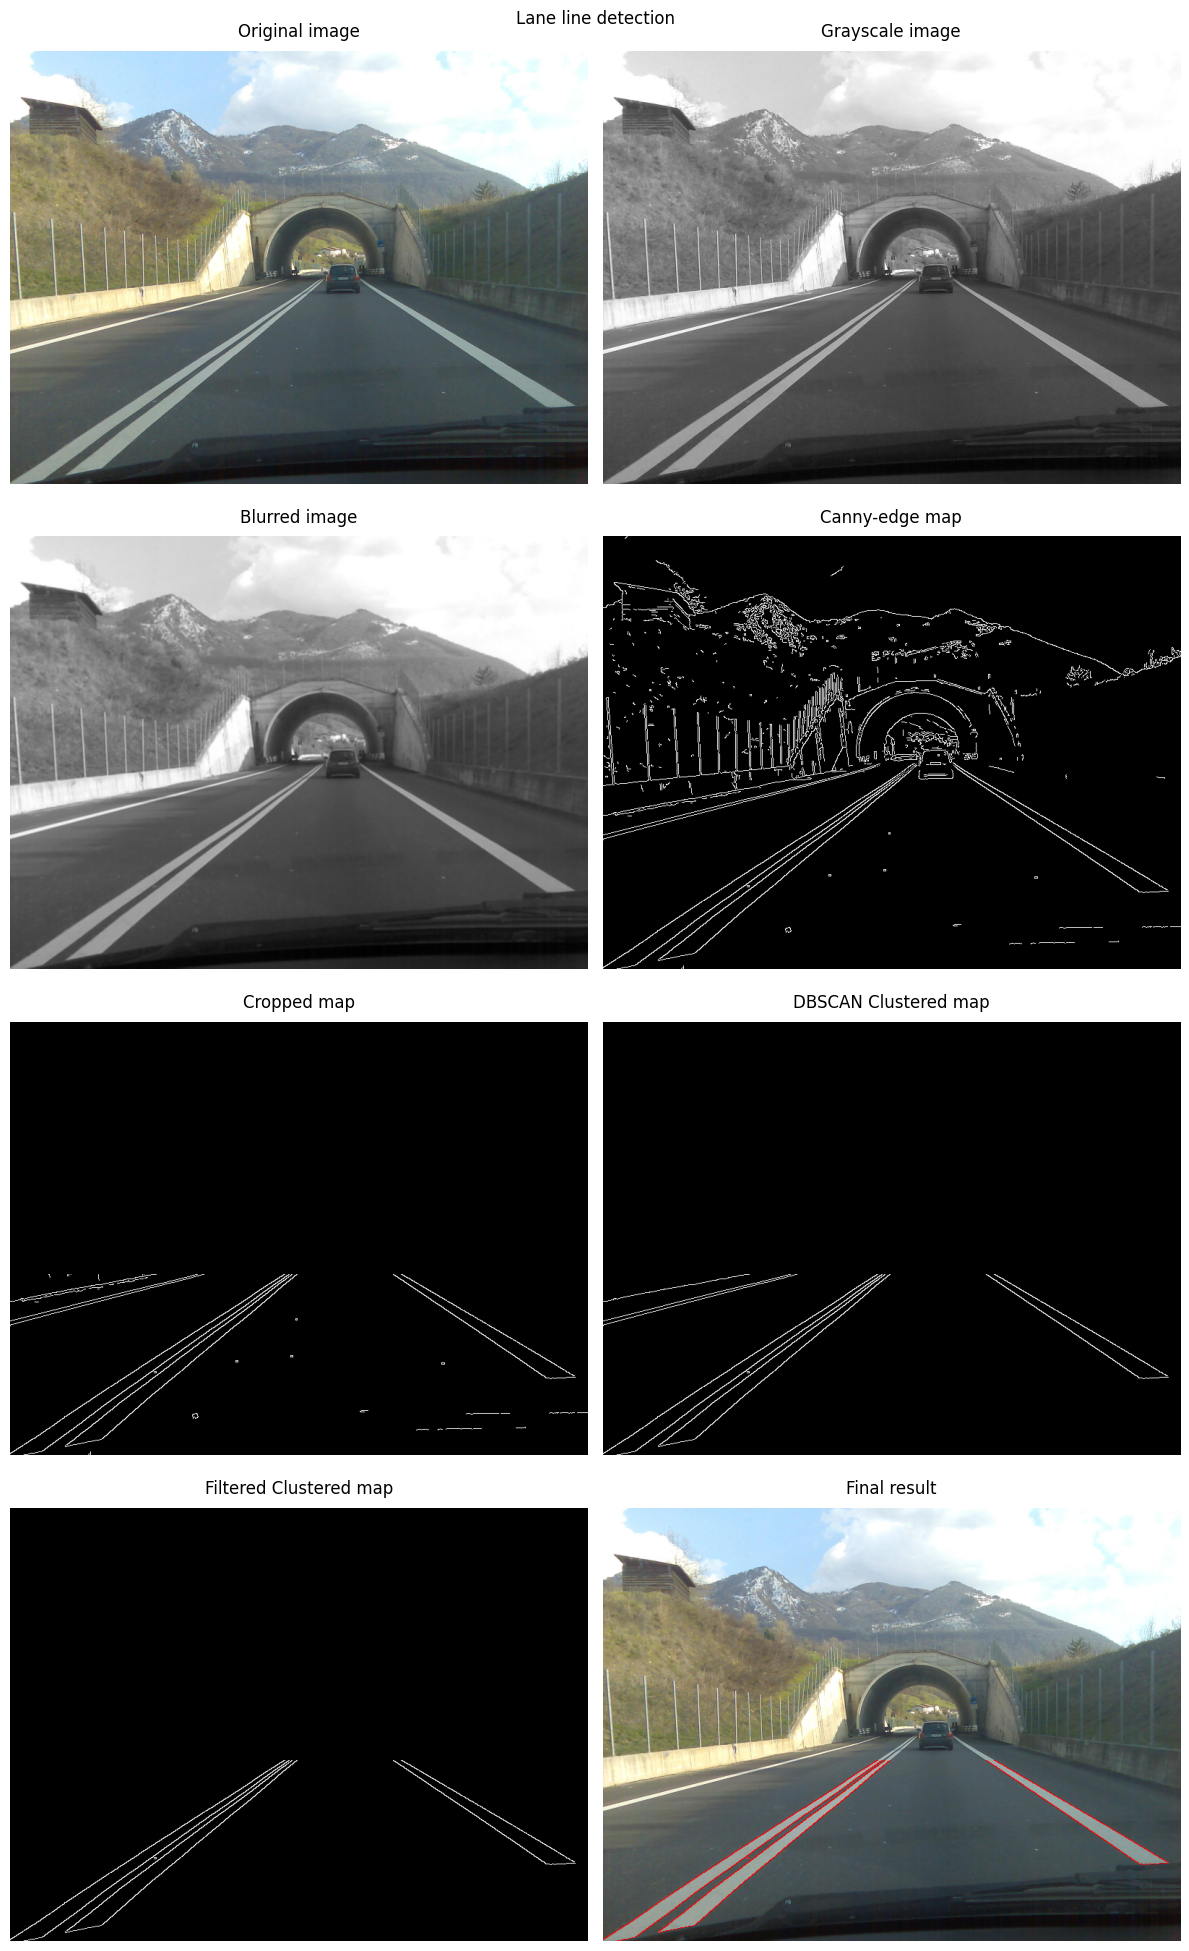

In [40]:
# Graphic results

import math
import numpy as np
import matplotlib.pyplot as plt

# Input data
n_img_cols = 2
n_img_rows = math.ceil(len(images_dict) / n_img_cols)

# Solution
_, axes = plt.subplots(n_img_rows, n_img_cols, figsize=(12, 5 * n_img_rows))
axes_list = np.array(axes).flatten()

for idx, (img_name, img_data) in enumerate(images_dict.items()):
    ax = axes_list[idx]
    ax.set_title(img_name, pad=10, loc='center', color='black')
    if len(img_data.shape) == 3:
        ax.imshow(img_data)
    else:
        ax.imshow(img_data, cmap='gray')
    ax.axis(False)

# remove empty charts
for idx in range(len(images_dict), len(axes_list)):
    axes_list[idx].remove()

# Plot
plt.suptitle("Lane line detection")
plt.tight_layout()
plt.show()


### Conclusion
In light of the drawbacks of the Hough transform discussed in the lecture — particularly its high computational complexity and the significant time required for line detection — an optimized approach was proposed and implemented.The core idea is to replace the Hough transform with the DBSCAN density-based clustering algorithm. The primary advantage of this method over KMeans is that it does not require a predefined number of clusters and inherently filters out geometric noise. Based on the clustering results, a dictionary mapping cluster IDs to their respective point counts is generated. Next, a threshold filtering based on the minimum number of pixels per cluster is applied to eliminate random artifacts.
To analyze the geometry of the filtered clusters, Principal Component Analysis (PCA) is utilized. This allows for the analytical calculation of the relative variance and the tilt angle of each cluster. The closer the explained variance ratio is to one, the more the cluster shape resembles a perfect straight line (alternatively, the linear correlation of pixels within the cluster can be computed). The final stage of the algorithm involves discarding noisy lines by filtering them based on the tilt angle of the resulting "eigenvector."
In this specific scenario, this approach demonstrated significantly better performance in detecting road markings.
I would be interested to hear your opinion on whether this Computer Vision approach is viable.